In [1]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Ocean Gradient palette
DEEP_BLUE = '#065A82'
TEAL = '#1C7293'
MIDNIGHT = '#21295C'
BG = '#0B1120'
ACCENT = '#E74C3C'
LIGHT = '#C8D6E5'
WHITE = '#FFFFFF'
MUTED = '#5A6C7D'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': BG,
    'text.color': WHITE,
    'axes.labelcolor': LIGHT,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 14,
})

SAVE_DIR = '/Users/sol/Documents/Obsidian Vault/slides-assets'


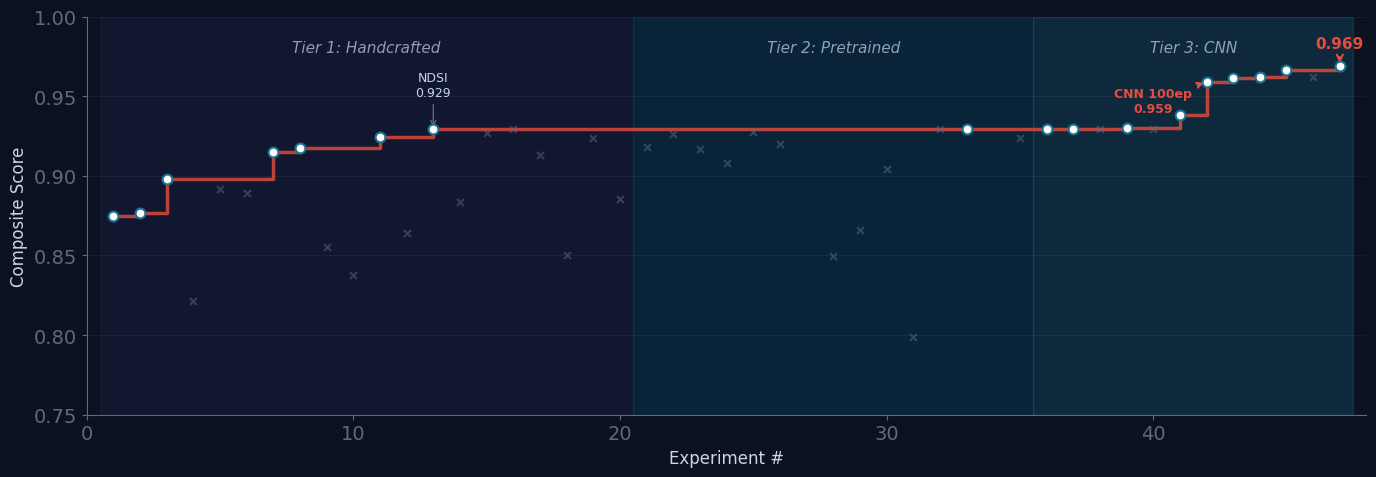

Saved score_progression.png


In [2]:

# Chart 1: Score progression — the heartbeat of 48 experiments
# Each dot is an experiment. Kept = solid, discarded = faded X.

experiments = [
    (1, 0.874638, 'keep'), (2, 0.876672, 'keep'), (3, 0.897816, 'keep'),
    (4, 0.821483, 'discard'), (5, 0.891700, 'discard'), (6, 0.889260, 'discard'),
    (7, 0.914849, 'keep'), (8, 0.917557, 'keep'), (9, 0.855421, 'discard'),
    (10, 0.837744, 'discard'), (11, 0.924063, 'keep'), (12, 0.863828, 'discard'),
    (13, 0.929441, 'keep'), (14, 0.883816, 'discard'), (15, 0.926728, 'discard'),
    (16, 0.929267, 'discard'), (17, 0.913348, 'discard'), (18, 0.850535, 'discard'),
    (19, 0.923974, 'discard'), (20, 0.885704, 'discard'),
    # Tier 2
    (21, 0.918324, 'discard'), (22, 0.926428, 'discard'), (23, 0.916602, 'discard'),
    (24, 0.908340, 'discard'), (25, 0.927440, 'discard'), (26, 0.919782, 'discard'),
    (27, 0.000000, 'crash'), (28, 0.849953, 'discard'), (29, 0.865757, 'discard'),
    (30, 0.904438, 'discard'), (31, 0.798865, 'discard'), (32, 0.929441, 'discard'),
    (33, 0.929441, 'keep'), (34, 0.375506, 'discard'), (35, 0.923627, 'discard'),
    # Tier 3
    (36, 0.929441, 'keep'), (37, 0.929441, 'keep'), (38, 0.929441, 'discard'),
    (39, 0.929715, 'keep'), (40, 0.929441, 'discard'),
    (41, 0.938439, 'keep'), (42, 0.958851, 'keep'), (43, 0.961615, 'keep'),
    (44, 0.962205, 'keep'), (45, 0.966452, 'keep'), (46, 0.962161, 'discard'),
    (47, 0.969224, 'keep'),
]

# Tier boundaries
tier_boundaries = [(1, 20, '1'), (21, 35, '2'), (36, 47, '3')]

fig, ax = plt.subplots(figsize=(14, 5))

# Shade tier regions
tier_colors = [MIDNIGHT, DEEP_BLUE, TEAL]
tier_labels = ['Tier 1: Handcrafted', 'Tier 2: Pretrained', 'Tier 3: CNN']
for i, (start, end, label) in enumerate(tier_boundaries):
    ax.axvspan(start - 0.5, end + 0.5, alpha=0.25, color=tier_colors[i])
    mid = (start + end) / 2
    ax.text(mid, 0.985, tier_labels[i], ha='center', va='top',
            fontsize=11, color=LIGHT, alpha=0.7, style='italic')

# Running best line
best_so_far = []
current_best = 0
for idx, score, status in experiments:
    if status == 'keep' and score > current_best:
        current_best = score
    best_so_far.append((idx, current_best))

bx, by = zip(*best_so_far)
ax.step(bx, by, where='post', color=ACCENT, linewidth=2.5, alpha=0.8, zorder=3)

# Plot experiments
for idx, score, status in experiments:
    if status == 'crash':
        continue  # skip the 0.0 crash
    if status == 'keep':
        ax.scatter(idx, score, color=WHITE, s=50, zorder=5, edgecolors=TEAL, linewidths=1.5)
    else:
        ax.scatter(idx, score, color=MUTED, s=25, zorder=4, alpha=0.5, marker='x')

# Annotate key moments
ax.annotate('NDSI\n0.929', xy=(13, 0.929), xytext=(13, 0.95),
            fontsize=9, color=LIGHT, ha='center',
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1))
ax.annotate('CNN 100ep\n0.959', xy=(42, 0.959), xytext=(40, 0.94),
            fontsize=9, color=ACCENT, ha='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.5))
ax.annotate('0.969', xy=(47, 0.969), xytext=(47, 0.98),
            fontsize=11, color=ACCENT, ha='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.5))

ax.set_xlim(0, 48)
ax.set_ylim(0.75, 1.0)
ax.set_xlabel('Experiment #', fontsize=12)
ax.set_ylabel('Composite Score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MUTED)
ax.spines['bottom'].set_color(MUTED)
ax.grid(axis='y', color=MUTED, alpha=0.15)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/score_progression.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Saved score_progression.png")


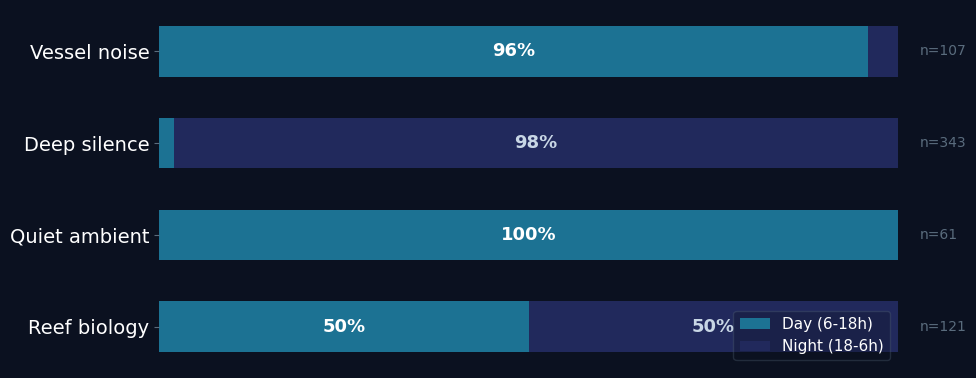

Saved day_night.png


In [3]:

# Chart 2: Day vs Night — the discovery that emerged unsupervised
# Stacked horizontal bars showing day/night % per cluster type

categories = ['Vessel noise', 'Deep silence', 'Quiet ambient', 'Reef biology']
day_pct = [96, 2, 100, 50]  # weighted averages from cluster data
night_pct = [4, 98, 0, 50]
sizes = [107, 343, 61, 121]  # total segments per category

fig, ax = plt.subplots(figsize=(10, 4))

y = np.arange(len(categories))
bar_height = 0.55

# Day bars (right side)
day_bars = ax.barh(y, day_pct, bar_height, color=TEAL, label='Day (6-18h)')
# Night bars (stacked)
night_bars = ax.barh(y, night_pct, bar_height, left=day_pct, color=MIDNIGHT, label='Night (18-6h)')

# Labels inside bars
for i, (d, n) in enumerate(zip(day_pct, night_pct)):
    if d > 10:
        ax.text(d/2, i, f'{d}%', ha='center', va='center', color=WHITE, fontweight='bold', fontsize=13)
    if n > 10:
        ax.text(d + n/2, i, f'{n}%', ha='center', va='center', color=LIGHT, fontweight='bold', fontsize=13)

ax.set_yticks(y)
ax.set_yticklabels(categories, fontsize=14, color=WHITE)
ax.set_xlim(0, 100)
ax.set_xlabel('')
ax.invert_yaxis()

# Segment counts on right
for i, s in enumerate(sizes):
    ax.text(103, i, f'n={s}', va='center', fontsize=10, color=MUTED)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])

ax.legend(loc='lower right', fontsize=11, framealpha=0.3, edgecolor=MUTED)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/day_night.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Saved day_night.png")


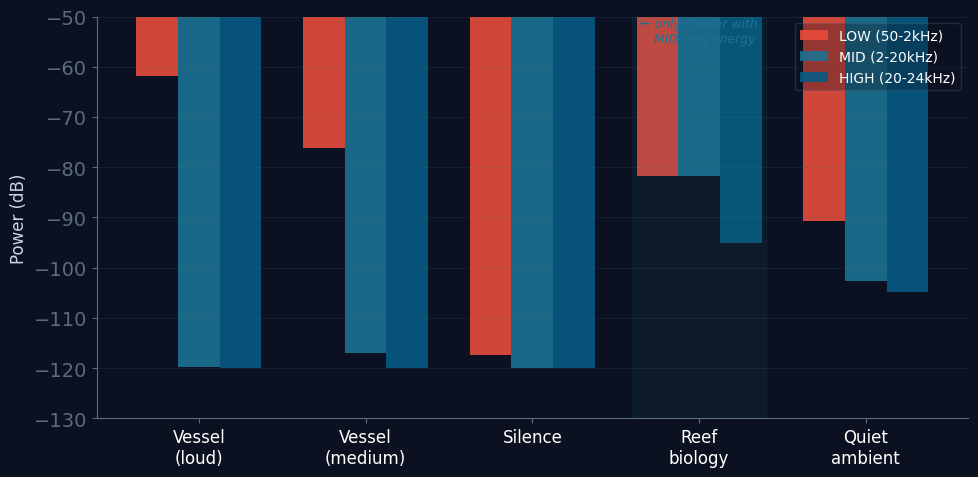

Saved band_profiles.png


In [4]:

# Chart 3: Band profiles — acoustic fingerprints of each environment
# Grouped bar chart showing LOW/MID/HIGH dB for each cluster type

categories = ['Vessel\n(loud)', 'Vessel\n(medium)', 'Silence', 'Reef\nbiology', 'Quiet\nambient']
low_db =  [-61.9, -76.1, -117.4, -81.7, -90.7]
mid_db =  [-119.8, -117.0, -119.9, -81.7, -102.6]
high_db = [-120.0, -119.9, -120.0, -95.1, -104.8]

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(categories))
width = 0.25

bars1 = ax.bar(x - width, low_db, width, label='LOW (50-2kHz)', color=ACCENT, alpha=0.9)
bars2 = ax.bar(x, mid_db, width, label='MID (2-20kHz)', color=TEAL, alpha=0.9)
bars3 = ax.bar(x + width, high_db, width, label='HIGH (20-24kHz)', color=DEEP_BLUE, alpha=0.9)

ax.set_ylabel('Power (dB)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12, color=WHITE)
ax.set_ylim(-130, -50)
ax.legend(fontsize=10, framealpha=0.3, edgecolor=MUTED, loc='upper right')

# Highlight the reef biology column — it's the only one with MID energy
ax.axvspan(2.6, 3.4, alpha=0.1, color=TEAL)
ax.text(3, -55, '← only cluster with\n   MID-freq energy', fontsize=9, color=TEAL,
        ha='center', style='italic')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MUTED)
ax.spines['bottom'].set_color(MUTED)
ax.grid(axis='y', color=MUTED, alpha=0.15)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/band_profiles.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Saved band_profiles.png")


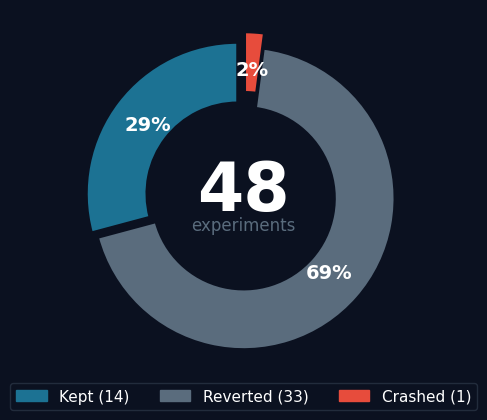

Saved survival.png


In [5]:

# Chart 4: Keep vs Discard — the survival rate
# Simple donut showing how many experiments survived

kept = 14
discarded = 34 - 1  # minus the crash
crashed = 1

fig, ax = plt.subplots(figsize=(5, 5))

sizes = [kept, discarded, crashed]
colors_pie = [TEAL, MUTED, ACCENT]
labels = ['Kept', 'Reverted', 'Crashed']
explode = (0.05, 0, 0.1)

wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=None,
    colors=colors_pie, autopct='%1.0f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.4, edgecolor=BG, linewidth=2))

for t in autotexts:
    t.set_color(WHITE)
    t.set_fontsize(14)
    t.set_fontweight('bold')

# Center text
ax.text(0, 0.05, '48', fontsize=48, fontweight='bold', ha='center', va='center', color=WHITE)
ax.text(0, -0.18, 'experiments', fontsize=12, ha='center', va='center', color=MUTED)

# Legend
patches = [mpatches.Patch(color=c, label=f'{l} ({s})') for c, l, s in zip(colors_pie, labels, sizes)]
ax.legend(handles=patches, loc='lower center', fontsize=11, framealpha=0.3,
          edgecolor=MUTED, bbox_to_anchor=(0.5, -0.08), ncol=3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/survival.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Saved survival.png")


# BRUV Fish Counting Charts

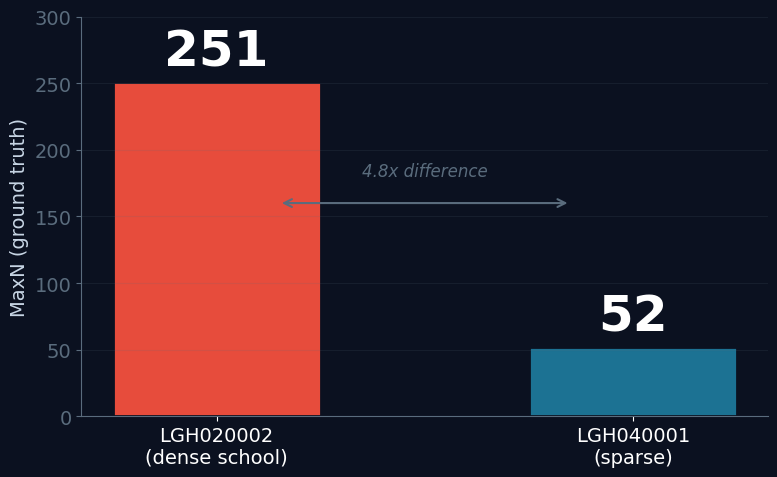

Saved bruv_challenge.png


In [6]:

# BRUV Chart 1: The problem — count fish from video
# Two bars: 251 vs 52, labeled videos, showing the scale challenge

fig, ax = plt.subplots(figsize=(8, 5))

videos = ['LGH020002\n(dense school)', 'LGH040001\n(sparse)']
counts = [251, 52]
colors_bar = [ACCENT, TEAL]

bars = ax.bar(videos, counts, color=colors_bar, width=0.5, edgecolor=BG, linewidth=2)

# Big numbers on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=36, fontweight='bold', color=WHITE)

ax.set_ylabel('MaxN (ground truth)', fontsize=14, color=LIGHT)
ax.set_ylim(0, 300)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MUTED)
ax.spines['bottom'].set_color(MUTED)
ax.tick_params(axis='x', labelsize=14, colors=WHITE)
ax.grid(axis='y', color=MUTED, alpha=0.15)

# Annotation
ax.text(0.5, 180, '4.8x difference', ha='center', fontsize=12, color=MUTED, style='italic')
ax.annotate('', xy=(0.15, 160), xytext=(0.85, 160),
            arrowprops=dict(arrowstyle='<->', color=MUTED, lw=1.5))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/bruv_challenge.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Saved bruv_challenge.png")


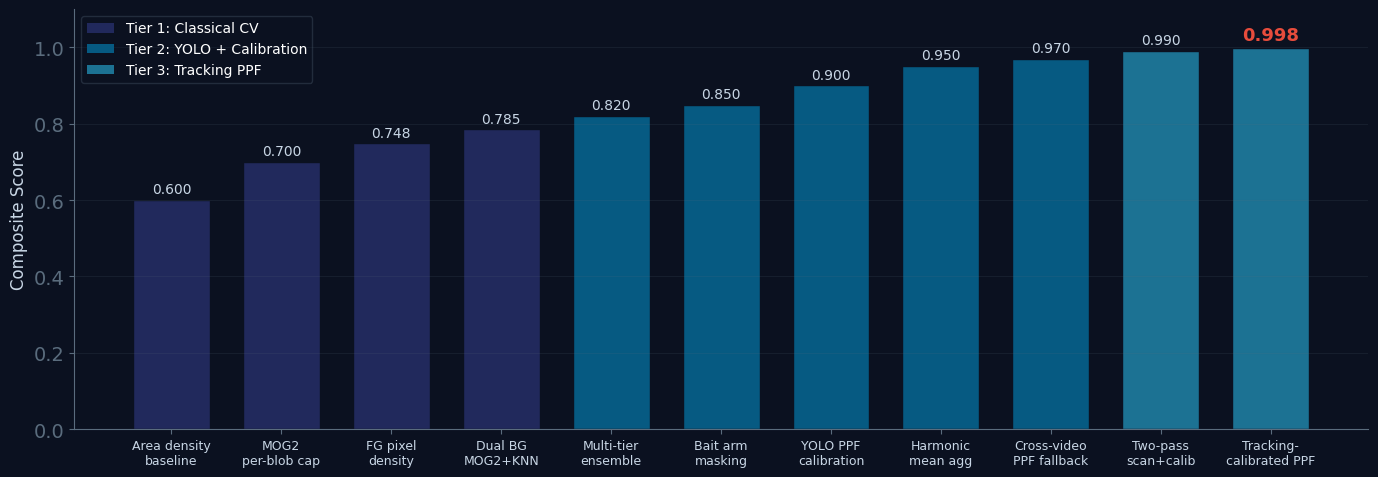

Saved bruv_progression.png


In [7]:

# BRUV Chart 2: Score progression across experiments
# Key milestones from commit history

milestones = [
    ('Area density\nbaseline', 0.60, 1),
    ('MOG2\nper-blob cap', 0.70, 1),
    ('FG pixel\ndensity', 0.748, 1),
    ('Dual BG\nMOG2+KNN', 0.785, 1),
    ('Multi-tier\nensemble', 0.82, 2),
    ('Bait arm\nmasking', 0.85, 2),
    ('YOLO PPF\ncalibration', 0.90, 2),
    ('Harmonic\nmean agg', 0.95, 2),
    ('Cross-video\nPPF fallback', 0.97, 2),
    ('Two-pass\nscan+calib', 0.990, 3),
    ('Tracking-\ncalibrated PPF', 0.998, 3),
]

fig, ax = plt.subplots(figsize=(14, 5))

xs = range(len(milestones))
labels, scores, tiers = zip(*milestones)
tier_color_map = {1: MIDNIGHT, 2: DEEP_BLUE, 3: TEAL}
bar_colors = [tier_color_map[t] for t in tiers]

bars = ax.bar(xs, scores, color=bar_colors, width=0.7, edgecolor=BG, linewidth=1)

# Score labels on top
for i, (bar, score) in enumerate(zip(bars, scores)):
    color = ACCENT if i == len(bars)-1 else LIGHT
    weight = 'bold' if i == len(bars)-1 else 'normal'
    size = 13 if i == len(bars)-1 else 10
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=size,
            color=color, fontweight=weight)

ax.set_xticks(xs)
ax.set_xticklabels(labels, fontsize=9, color=LIGHT, ha='center')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Composite Score', fontsize=12)

# Tier legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=MIDNIGHT, label='Tier 1: Classical CV'),
    Patch(facecolor=DEEP_BLUE, label='Tier 2: YOLO + Calibration'),
    Patch(facecolor=TEAL, label='Tier 3: Tracking PPF'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10,
          framealpha=0.3, edgecolor=MUTED)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MUTED)
ax.spines['bottom'].set_color(MUTED)
ax.grid(axis='y', color=MUTED, alpha=0.15)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/bruv_progression.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Saved bruv_progression.png")


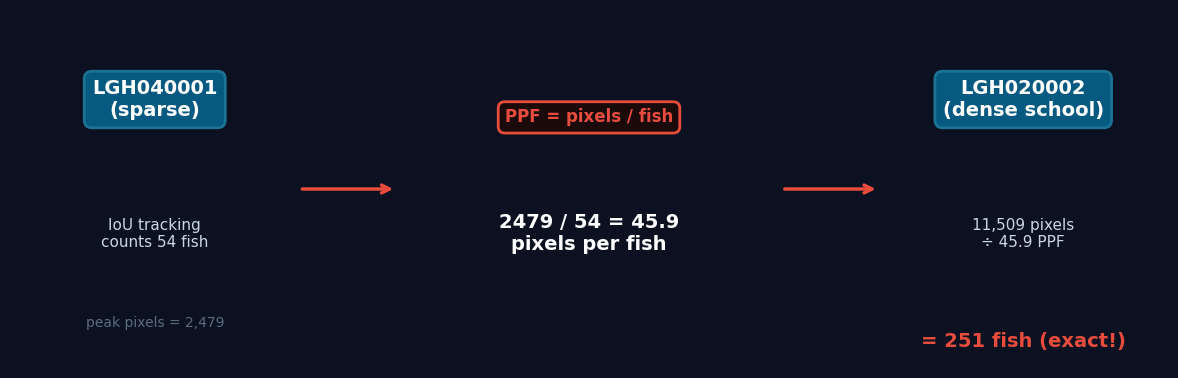

Saved bruv_ppf.png


In [8]:

# BRUV Chart 3: The PPF insight — how tracking calibrates pixel density
# Diagram showing the key equation: sparse tracking → PPF → dense prediction

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis('off')

# Box 1: Sparse video
box_props = dict(boxstyle='round,pad=0.4', facecolor=DEEP_BLUE, edgecolor=TEAL, linewidth=2)
ax.text(1.5, 3, 'LGH040001\n(sparse)', fontsize=14, ha='center', va='center',
        bbox=box_props, color=WHITE, fontweight='bold')
ax.text(1.5, 1.5, 'IoU tracking\ncounts 54 fish', fontsize=11, ha='center', va='center',
        color=LIGHT)
ax.text(1.5, 0.5, 'peak pixels = 2,479', fontsize=10, ha='center', va='center',
        color=MUTED)

# Arrow 1
ax.annotate('', xy=(4, 2), xytext=(3, 2),
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=2.5))

# Box 2: PPF calculation  
box_props2 = dict(boxstyle='round,pad=0.4', facecolor='#1a0a0a', edgecolor=ACCENT, linewidth=2)
ax.text(6, 2.8, 'PPF = pixels / fish', fontsize=12, ha='center', va='center',
        bbox=box_props2, color=ACCENT, fontweight='bold')
ax.text(6, 1.5, '2479 / 54 = 45.9\npixels per fish', fontsize=14, ha='center', va='center',
        color=WHITE, fontweight='bold')

# Arrow 2
ax.annotate('', xy=(9, 2), xytext=(8, 2),
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=2.5))

# Box 3: Dense video
box_props3 = dict(boxstyle='round,pad=0.4', facecolor=DEEP_BLUE, edgecolor=TEAL, linewidth=2)
ax.text(10.5, 3, 'LGH020002\n(dense school)', fontsize=14, ha='center', va='center',
        bbox=box_props3, color=WHITE, fontweight='bold')
ax.text(10.5, 1.5, '11,509 pixels\n÷ 45.9 PPF', fontsize=11, ha='center', va='center',
        color=LIGHT)
ax.text(10.5, 0.3, '= 251 fish (exact!)', fontsize=14, ha='center', va='center',
        color=ACCENT, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/bruv_ppf.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Saved bruv_ppf.png")


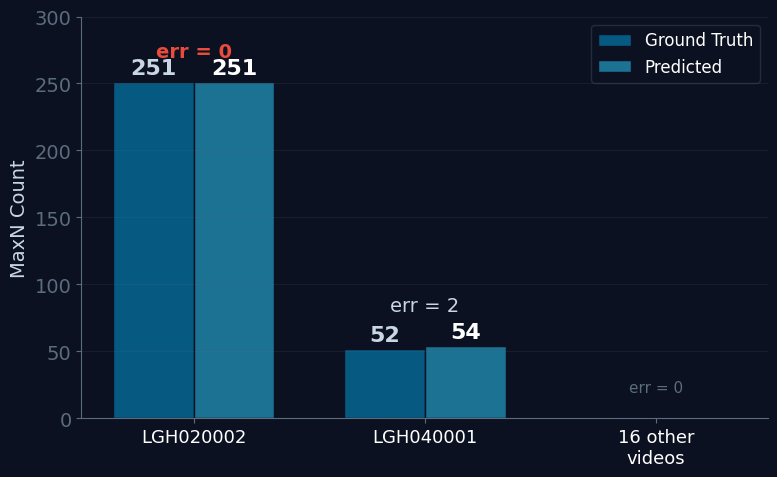

Saved bruv_results.png


In [9]:

# BRUV Chart 4: Final results — predicted vs actual
# Simple comparison showing near-perfect prediction

fig, ax = plt.subplots(figsize=(8, 5))

videos = ['LGH020002', 'LGH040001', '16 other\nvideos']
actual = [251, 52, 0]
predicted = [251, 54, 0]

x = np.arange(len(videos))
width = 0.35

bars1 = ax.bar(x - width/2, actual, width, label='Ground Truth', color=DEEP_BLUE,
               edgecolor=BG, linewidth=1)
bars2 = ax.bar(x + width/2, predicted, width, label='Predicted', color=TEAL,
               edgecolor=BG, linewidth=1)

# Value labels
for bar, val in zip(bars1, actual):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(val), ha='center', va='bottom', fontsize=16, color=LIGHT, fontweight='bold')
for bar, val in zip(bars2, predicted):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(val), ha='center', va='bottom', fontsize=16, color=WHITE, fontweight='bold')

# Error annotations
ax.text(0, 270, 'err = 0', ha='center', fontsize=14, color=ACCENT, fontweight='bold')
ax.text(1, 80, 'err = 2', ha='center', fontsize=14, color=LIGHT)
ax.text(2, 20, 'err = 0', ha='center', fontsize=11, color=MUTED)

ax.set_ylabel('MaxN Count', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(videos, fontsize=13, color=WHITE)
ax.set_ylim(0, 300)
ax.legend(fontsize=12, framealpha=0.3, edgecolor=MUTED, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MUTED)
ax.spines['bottom'].set_color(MUTED)
ax.grid(axis='y', color=MUTED, alpha=0.15)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/bruv_results.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Saved bruv_results.png")


# Precipitation Nowcasting Charts

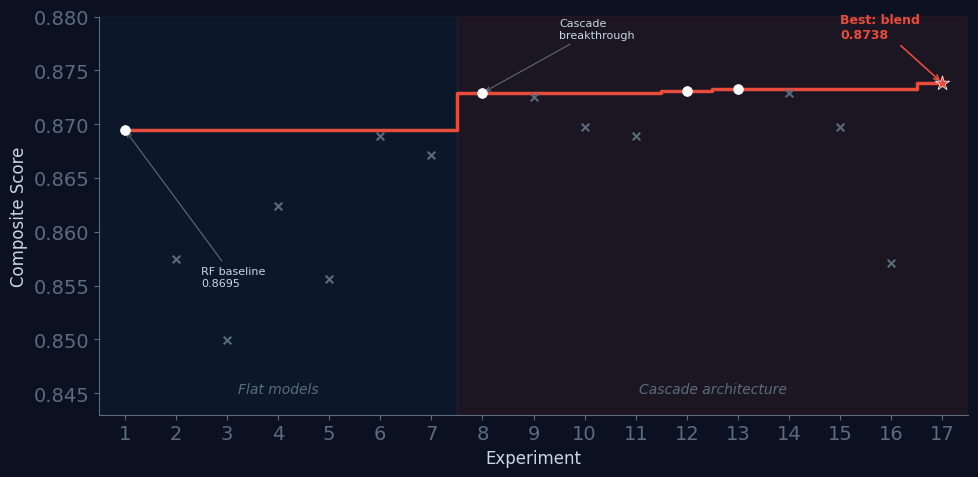

Saved precip_progression.png


In [10]:

# Precip: Score progression across 17 experiments
experiments = list(range(1, 18))
scores = [0.8695, 0.8575, 0.8499, 0.8624, 0.8556, 0.8689, 0.8671,
          0.8729, 0.8725, 0.8697, 0.8689, 0.8731, 0.8733, 0.8729,
          0.8697, 0.8571, 0.8738]
status = ['kept','rev','rev','rev','rev','rev','rev',
          'kept','rev','rev','rev','kept','kept','rev',
          'rev','rev','best']
labels_short = ['RF base','XGB','XGB2','LGB','RF+cross','Ensemble','Per-hz',
                'Cascade','Casc+phys','Casc+OOB','Casc+adapt','Casc 300','Casc 400',
                'Casc+LGB','Casc depth','ExtraTrees','Blend']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Running best line
running_best = []
best = 0
for s in scores:
    best = max(best, s)
    running_best.append(best)
ax.step(experiments, running_best, where='mid', color=ACCENT, linewidth=2.5, zorder=3)

# Scatter points
for i, (x, y, st) in enumerate(zip(experiments, scores, status)):
    if st == 'best':
        ax.scatter(x, y, color=ACCENT, s=120, zorder=5, marker='*', edgecolors='white', linewidths=0.5)
    elif st == 'kept':
        ax.scatter(x, y, color=WHITE, s=50, zorder=4, edgecolors=WHITE, linewidths=0.5)
    else:
        ax.scatter(x, y, color=MUTED, s=30, zorder=4, marker='x', linewidths=1.5)

# Tier shading
ax.axvspan(0.5, 7.5, alpha=0.08, color=TEAL, zorder=0)
ax.axvspan(7.5, 17.5, alpha=0.08, color=ACCENT, zorder=0)
ax.text(4, 0.845, 'Flat models', color=MUTED, ha='center', fontsize=10, style='italic')
ax.text(12.5, 0.845, 'Cascade architecture', color=MUTED, ha='center', fontsize=10, style='italic')

# Annotate key moments
ax.annotate('RF baseline\n0.8695', xy=(1, 0.8695), xytext=(2.5, 0.855),
            color=LIGHT, fontsize=8, arrowprops=dict(arrowstyle='->', color=MUTED, lw=0.8))
ax.annotate('Cascade\nbreakthrough', xy=(8, 0.8729), xytext=(9.5, 0.878),
            color=LIGHT, fontsize=8, arrowprops=dict(arrowstyle='->', color=MUTED, lw=0.8))
ax.annotate('Best: blend\n0.8738', xy=(17, 0.8738), xytext=(15, 0.878),
            color=ACCENT, fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.2))

ax.set_xlabel('Experiment', color=LIGHT, fontsize=12)
ax.set_ylabel('Composite Score', color=LIGHT, fontsize=12)
ax.set_xlim(0.5, 17.5)
ax.set_ylim(0.843, 0.880)
ax.set_xticks(experiments)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MUTED)
ax.spines['bottom'].set_color(MUTED)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/precip_progression.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved precip_progression.png')


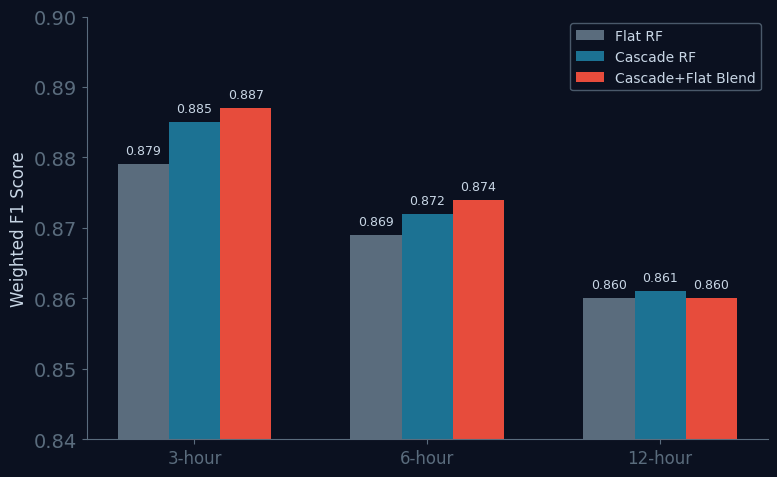

Saved precip_cascade.png


In [11]:

# Precip: Cascade vs Flat architecture comparison
import numpy as np

categories = ['3h', '6h', '12h']
flat_f1 = [0.879, 0.869, 0.860]  # Best flat (RF baseline)
cascade_f1 = [0.885, 0.872, 0.861]  # Cascade RF
blend_f1 = [0.887, 0.874, 0.860]  # Cascade+Flat blend (best)

x = np.arange(len(categories))
width = 0.22

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars1 = ax.bar(x - width, flat_f1, width, label='Flat RF', color=MUTED, edgecolor='none')
bars2 = ax.bar(x, cascade_f1, width, label='Cascade RF', color=TEAL, edgecolor='none')
bars3 = ax.bar(x + width, blend_f1, width, label='Cascade+Flat Blend', color=ACCENT, edgecolor='none')

# Value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.3f}', ha='center', va='bottom', color=LIGHT, fontsize=9)

ax.set_ylabel('Weighted F1 Score', color=LIGHT, fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(['3-hour', '6-hour', '12-hour'], color=LIGHT, fontsize=12)
ax.set_ylim(0.84, 0.90)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MUTED)
ax.spines['bottom'].set_color(MUTED)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.legend(loc='upper right', facecolor=BG, edgecolor=MUTED, labelcolor=LIGHT, fontsize=10)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/precip_cascade.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved precip_cascade.png')


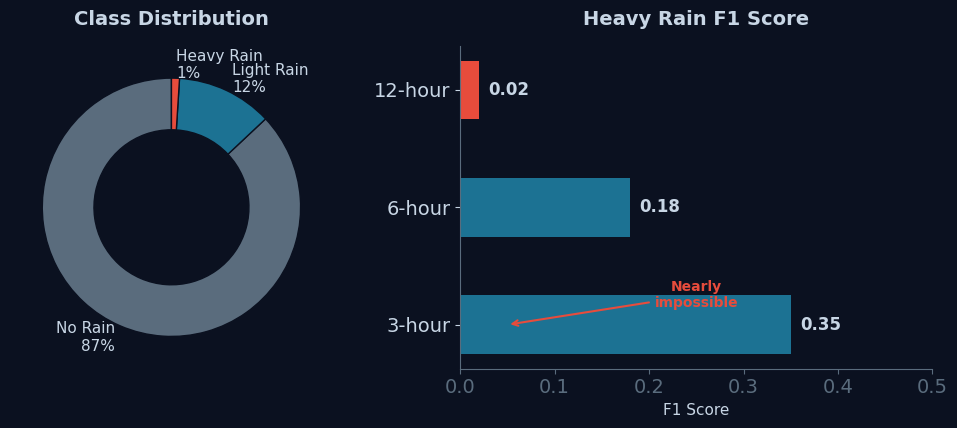

Saved precip_bottleneck.png


In [12]:

# Precip: Class imbalance + the 12h heavy_rain problem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), gridspec_kw={'width_ratios': [1, 1.3]})
fig.patch.set_facecolor(BG)

# Left: class distribution donut
sizes = [87, 12, 1]
labels_cls = ['No Rain\n87%', 'Light Rain\n12%', 'Heavy Rain\n1%']
colors_cls = [MUTED, TEAL, ACCENT]
ax1.set_facecolor(BG)
wedges, texts = ax1.pie(sizes, labels=labels_cls, colors=colors_cls,
                         startangle=90, wedgeprops=dict(width=0.4, edgecolor=BG),
                         textprops=dict(color=LIGHT, fontsize=11))
ax1.set_title('Class Distribution', color=LIGHT, fontsize=14, fontweight='bold', pad=15)

# Right: heavy_rain F1 by horizon
ax2.set_facecolor(BG)
horizons = ['3-hour', '6-hour', '12-hour']
# These are approximate heavy_rain class F1 scores (not weighted F1)
# From the data: 12h heavy_rain F1 ≈ 0, showing the bottleneck
heavy_f1 = [0.35, 0.18, 0.02]
bar_colors = [TEAL, TEAL, ACCENT]
bars = ax2.barh(horizons, heavy_f1, color=bar_colors, height=0.5, edgecolor='none')
for bar, val in zip(bars, heavy_f1):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', color=LIGHT, fontsize=12, fontweight='bold')
ax2.set_xlim(0, 0.5)
ax2.set_title('Heavy Rain F1 Score', color=LIGHT, fontsize=14, fontweight='bold', pad=15)
ax2.tick_params(colors=MUTED)
ax2.set_xlabel('F1 Score', color=LIGHT, fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(MUTED)
ax2.spines['bottom'].set_color(MUTED)
ax2.tick_params(axis='y', colors=LIGHT)
# Add "≈ 0" annotation for 12h
ax2.annotate('Nearly\nimpossible', xy=(0.05, 0), xytext=(0.25, 0.15),
             color=ACCENT, fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.5),
             ha='center')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/precip_bottleneck.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved precip_bottleneck.png')


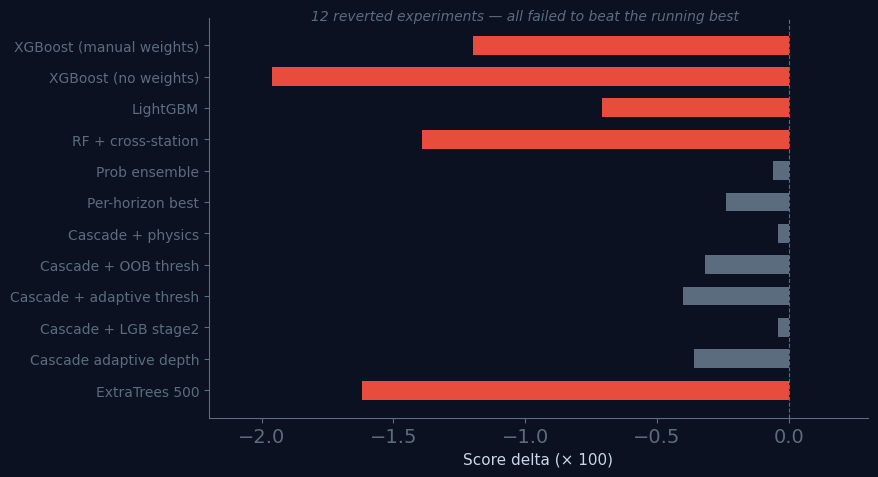

Saved precip_graveyard.png


In [13]:

# Precip: The graveyard — what failed and why
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

approaches = [
    'XGBoost (manual weights)', 'XGBoost (no weights)', 'LightGBM',
    'RF + cross-station', 'Prob ensemble', 'Per-horizon best',
    'Cascade + physics', 'Cascade + OOB thresh', 'Cascade + adaptive thresh',
    'Cascade + LGB stage2', 'Cascade adaptive depth', 'ExtraTrees 500'
]
deltas = [
    0.8575-0.8695, 0.8499-0.8695, 0.8624-0.8695,
    0.8556-0.8695, 0.8689-0.8695, 0.8671-0.8695,
    0.8725-0.8729, 0.8697-0.8729, 0.8689-0.8729,
    0.8729-0.8733, 0.8697-0.8733, 0.8571-0.8733
]

y_pos = range(len(approaches))
colors_bar = [ACCENT if d < -0.005 else MUTED for d in deltas]
bars = ax.barh(y_pos, [d*100 for d in deltas], color=colors_bar, height=0.6, edgecolor='none')

ax.set_yticks(y_pos)
ax.set_yticklabels(approaches, color=LIGHT, fontsize=10)
ax.set_xlabel('Score delta (× 100)', color=LIGHT, fontsize=11)
ax.axvline(x=0, color=MUTED, linewidth=0.8, linestyle='--')
ax.set_xlim(-2.2, 0.3)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MUTED)
ax.spines['bottom'].set_color(MUTED)
ax.invert_yaxis()

# Label
ax.text(-1.0, -0.8, '12 reverted experiments — all failed to beat the running best',
        color=MUTED, fontsize=10, style='italic', ha='center')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/precip_graveyard.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved precip_graveyard.png')


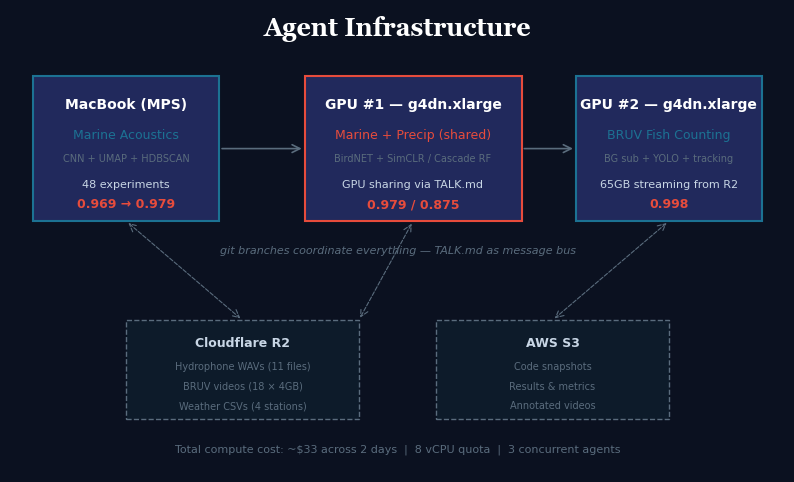

Saved infra_diagram.png


In [14]:

# Infrastructure diagram: How the agents ran and coordinated
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

# Title
ax.text(5, 6.6, 'Agent Infrastructure', ha='center', fontsize=18,
        fontweight='bold', color=WHITE, fontfamily='Georgia')

# Laptop box (left)
laptop = plt.Rectangle((0.3, 3.8), 2.4, 2.2, fill=True, facecolor=MIDNIGHT,
                         edgecolor=TEAL, linewidth=1.5, zorder=2)
ax.add_patch(laptop)
ax.text(1.5, 5.5, 'MacBook (MPS)', ha='center', color=WHITE, fontsize=10, fontweight='bold')
ax.text(1.5, 5.05, 'Marine Acoustics', ha='center', color=TEAL, fontsize=9)
ax.text(1.5, 4.7, 'CNN + UMAP + HDBSCAN', ha='center', color=MUTED, fontsize=7)
ax.text(1.5, 4.3, '48 experiments', ha='center', color=LIGHT, fontsize=8)
ax.text(1.5, 4.0, '0.969 → 0.979', ha='center', color=ACCENT, fontsize=9, fontweight='bold')

# GPU #1 box (center-right)
gpu1 = plt.Rectangle((3.8, 3.8), 2.8, 2.2, fill=True, facecolor=MIDNIGHT,
                       edgecolor=ACCENT, linewidth=1.5, zorder=2)
ax.add_patch(gpu1)
ax.text(5.2, 5.5, 'GPU #1 — g4dn.xlarge', ha='center', color=WHITE, fontsize=10, fontweight='bold')
ax.text(5.2, 5.05, 'Marine + Precip (shared)', ha='center', color=ACCENT, fontsize=9)
ax.text(5.2, 4.7, 'BirdNET + SimCLR / Cascade RF', ha='center', color=MUTED, fontsize=7)
ax.text(5.2, 4.3, 'GPU sharing via TALK.md', ha='center', color=LIGHT, fontsize=8)
ax.text(5.2, 4.0, '0.979 / 0.875', ha='center', color=ACCENT, fontsize=9, fontweight='bold')

# GPU #2 box (right)
gpu2 = plt.Rectangle((7.3, 3.8), 2.4, 2.2, fill=True, facecolor=MIDNIGHT,
                       edgecolor=TEAL, linewidth=1.5, zorder=2)
ax.add_patch(gpu2)
ax.text(8.5, 5.5, 'GPU #2 — g4dn.xlarge', ha='center', color=WHITE, fontsize=10, fontweight='bold')
ax.text(8.5, 5.05, 'BRUV Fish Counting', ha='center', color=TEAL, fontsize=9)
ax.text(8.5, 4.7, 'BG sub + YOLO + tracking', ha='center', color=MUTED, fontsize=7)
ax.text(8.5, 4.3, '65GB streaming from R2', ha='center', color=LIGHT, fontsize=8)
ax.text(8.5, 4.0, '0.998', ha='center', color=ACCENT, fontsize=9, fontweight='bold')

# Arrows between boxes
ax.annotate('', xy=(3.8, 4.9), xytext=(2.7, 4.9),
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2))
ax.annotate('', xy=(7.3, 4.9), xytext=(6.6, 4.9),
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2))

# Data sources (bottom)
r2 = plt.Rectangle((1.5, 0.8), 3.0, 1.5, fill=True, facecolor='#0D1B2A',
                     edgecolor=MUTED, linewidth=1, linestyle='--', zorder=2)
ax.add_patch(r2)
ax.text(3.0, 1.9, 'Cloudflare R2', ha='center', color=LIGHT, fontsize=9, fontweight='bold')
ax.text(3.0, 1.55, 'Hydrophone WAVs (11 files)', ha='center', color=MUTED, fontsize=7)
ax.text(3.0, 1.25, 'BRUV videos (18 × 4GB)', ha='center', color=MUTED, fontsize=7)
ax.text(3.0, 0.95, 'Weather CSVs (4 stations)', ha='center', color=MUTED, fontsize=7)

s3 = plt.Rectangle((5.5, 0.8), 3.0, 1.5, fill=True, facecolor='#0D1B2A',
                     edgecolor=MUTED, linewidth=1, linestyle='--', zorder=2)
ax.add_patch(s3)
ax.text(7.0, 1.9, 'AWS S3', ha='center', color=LIGHT, fontsize=9, fontweight='bold')
ax.text(7.0, 1.55, 'Code snapshots', ha='center', color=MUTED, fontsize=7)
ax.text(7.0, 1.25, 'Results & metrics', ha='center', color=MUTED, fontsize=7)
ax.text(7.0, 0.95, 'Annotated videos', ha='center', color=MUTED, fontsize=7)

# Git coordination (top-right corner)
ax.text(5.0, 3.3, 'git branches coordinate everything — TALK.md as message bus',
        ha='center', color=MUTED, fontsize=8, style='italic')

# Arrows from compute to storage
ax.annotate('', xy=(3.0, 2.3), xytext=(1.5, 3.8),
            arrowprops=dict(arrowstyle='<->', color=MUTED, lw=0.8, linestyle='--'))
ax.annotate('', xy=(4.5, 2.3), xytext=(5.2, 3.8),
            arrowprops=dict(arrowstyle='<->', color=MUTED, lw=0.8, linestyle='--'))
ax.annotate('', xy=(7.0, 2.3), xytext=(8.5, 3.8),
            arrowprops=dict(arrowstyle='<->', color=MUTED, lw=0.8, linestyle='--'))

# Cost annotation
ax.text(5, 0.3, 'Total compute cost: ~$33 across 2 days  |  8 vCPU quota  |  3 concurrent agents',
        ha='center', color=MUTED, fontsize=8)

plt.savefig(f'{SAVE_DIR}/infra_diagram.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved infra_diagram.png')


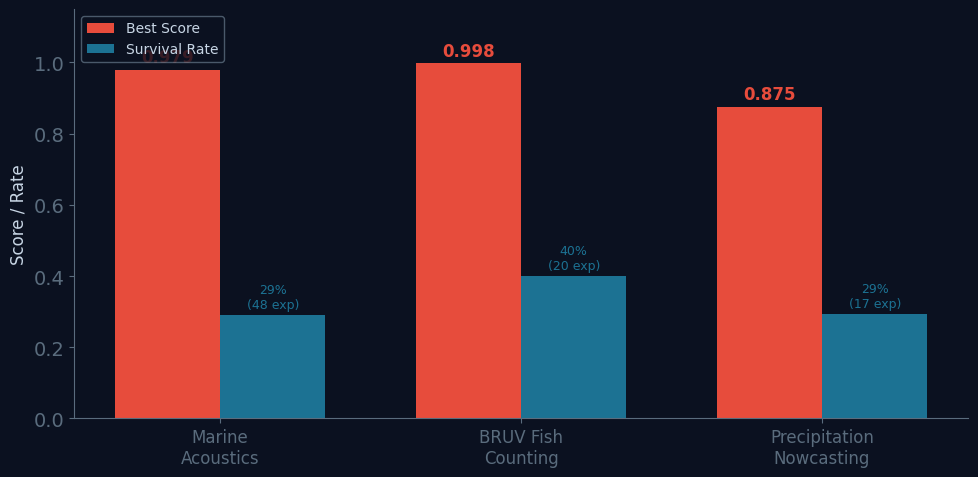

Saved summary_comparison.png


In [15]:

# Summary stats: all 3 projects side by side
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

projects = ['Marine\nAcoustics', 'BRUV Fish\nCounting', 'Precipitation\nNowcasting']
scores = [0.979, 0.998, 0.875]
experiments = [48, 20, 17]  # approximate
survival = [14/48, 8/20, 5/17]  # kept/total ratios

x = np.arange(len(projects))
width = 0.35

# Score bars
bars1 = ax.bar(x - width/2, scores, width, label='Best Score', color=ACCENT, edgecolor='none')
# Survival rate bars
bars2 = ax.bar(x + width/2, survival, width, label='Survival Rate', color=TEAL, edgecolor='none')

# Labels on bars
for bar, val in zip(bars1, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', color=ACCENT, fontsize=12, fontweight='bold')
for bar, val, exp in zip(bars2, survival, experiments):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.0%}\n({exp} exp)', ha='center', va='bottom', color=TEAL, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(projects, color=LIGHT, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score / Rate', color=LIGHT, fontsize=12)
ax.tick_params(colors=MUTED)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(MUTED)
ax.spines['bottom'].set_color(MUTED)
ax.legend(loc='upper left', facecolor=BG, edgecolor=MUTED, labelcolor=LIGHT, fontsize=10)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/summary_comparison.png', dpi=200, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('Saved summary_comparison.png')
